In [1]:
import pandas as pd

### External Control Arm Construction

#### Load data from the single arm trial (SAT) (treatment arm) and RWD controls (control arm)

In [2]:
df_SAT = pd.read_csv("../data/SAT.csv")
df_external_control = pd.read_csv("../data/external_controls.csv")
df_combined = pd.concat([df_SAT, df_external_control]).reset_index(drop=True)

##### SAT:

In [3]:
display(df_SAT.head())


,age,female,extranod,stage2,medwidsi_S,medwidsi_N,chemo,time,status
0,27.00,1,0,1,0,1,1,4.100,1
1,42.63,1,0,1,0,1,1,5.500,1
2,29.00,1,0,1,1,0,1,1.700,1
3,37.00,0,0,1,0,1,1,0.003,1
4,29.00,0,0,1,0,1,1,24.600,2


##### external control:

In [4]:
display(df_external_control.head())

,age,female,extranod,stage2,medwidsi_S,medwidsi_N,chemo,time,status
0,64.0,1,0,0,0,1,0,3.1,2
1,63.0,0,0,0,0,1,0,15.9,2
2,17.0,0,0,1,0,1,0,0.9,1
3,63.0,0,0,1,0,1,0,13.1,2
4,21.0,0,0,1,0,0,0,35.9,0


Note: Datasets are already preprocessed:
- data sets harmonized (same columns)
- categorical columns are already expanded (gender, medwidsi) 
- no duplicates, no missing values


#### Comparison of SAT and external control arm:

##### baseline covariates

In [5]:
baseline_covariates = [
    "age", "female", "extranod", "stage2", "medwidsi_S", "medwidsi_N"
]

from causalml.match import create_table_one

table_one = create_table_one(
    data=df_combined,
    treatment_col="chemo",
    features=baseline_covariates,
    with_std=True,
    with_counts=True,
)

table_one

,Control,Treatment,SMD
Variable,,,
n,614,249,
age,35.84 (16.31),33.77 (12.86),-0.1412
extranod,0.05 (0.21),0.20 (0.40),0.4783
female,0.46 (0.50),0.47 (0.50),0.0147
medwidsi_N,0.62 (0.49),0.33 (0.47),-0.6051
medwidsi_S,0.34 (0.48),0.31 (0.46),-0.0733
stage2,0.57 (0.50),0.88 (0.33),0.7415


Standardized mean differences (SMDs) compare the cohorts on a common scale. Values closer to zero indicate better balance.

==> cohorts differ considerably in disease-stage variables, especially stage2, extranod, and medwidsi_N (could also be formulated as a question / test)

##### follow-up and outcome

In [6]:
outcome_summary = pd.DataFrame({
    "SAT": {
        "participants": len(df_SAT),
        "median follow-up time": df_SAT["time"].median(),
        "status 0": (df_SAT["status"] == 0).sum(),
        "status 1": (df_SAT["status"] == 1).sum(),
        "status 2": (df_SAT["status"] == 2).sum(),
    },
    "External control": {
        "participants": len(df_external_control),
        "median follow-up time": df_external_control["time"].median(),
        "status 0": (df_external_control["status"] == 0).sum(),
        "status 1": (df_external_control["status"] == 1).sum(),
        "status 2": (df_external_control["status"] == 2).sum(),
    },
})
outcome_summary

,SAT,External control
participants,249.0,614.0
median follow-up time,15.6,13.0
status 0,146.0,293.0
status 1,61.0,228.0
status 2,42.0,93.0


#### Estimate propensity scores using superlearner from R4R tools

In [7]:
from R4R_tools.propensity_superlearner import estimate_propensity
df_combined["propensity_score"] = estimate_propensity(df_combined.drop(columns=["time", "status"]), col_group="chemo") # event time and indicator not used for ps estimation
df_combined

c:\Users\aweller\Documents\r4r-training\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,age,female,extranod,stage2,medwidsi_S,medwidsi_N,chemo,time,status,propensity_score
0,27.00,1,0,1,0,1,1,4.100,1,0.192891
1,42.63,1,0,1,0,1,1,5.500,1,0.302352
2,29.00,1,0,1,1,0,1,1.700,1,0.290817
3,37.00,0,0,1,0,1,1,0.003,1,0.375284
4,29.00,0,0,1,0,1,1,24.600,2,0.315068
...,...,...,...,...,...,...,...,...,...,...
858,58.00,1,0,0,0,1,0,0.700,1,0.152792
859,26.74,0,0,1,1,0,0,15.400,0,0.183826
860,64.13,1,0,0,0,1,0,2.900,1,0.590371
861,23.24,1,0,1,1,0,0,6.200,0,0.279387


#### plot propensity score distributions (before matching)

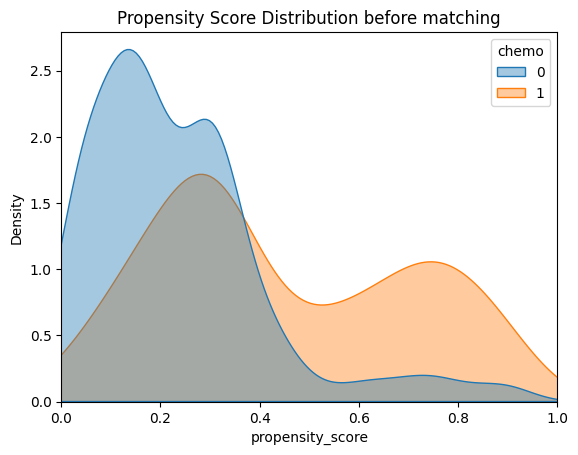

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.kdeplot(
    data=df_combined,
    x="propensity_score",
    hue="chemo",
    common_norm=False,
    fill=True,
    alpha=0.4
)
plt.xlim(0, 1)  
plt.title("Propensity Score Distribution before matching")
plt.show()

#### 1 to 2 Matching based on propensity scores (2 control unit to each treated unit)

In [9]:
from R4R_tools.matching import control_matching

matching_ratio = 2
df_matched = control_matching(df_combined, treatment_col="chemo", score_cols=["propensity_score"], ratio=matching_ratio, caliper=0.05, replace = False, random_state=0)
df_matched["chemo"].value_counts() # size of treatment and control arm

chemo
0    330
1    173
Name: count, dtype: int64

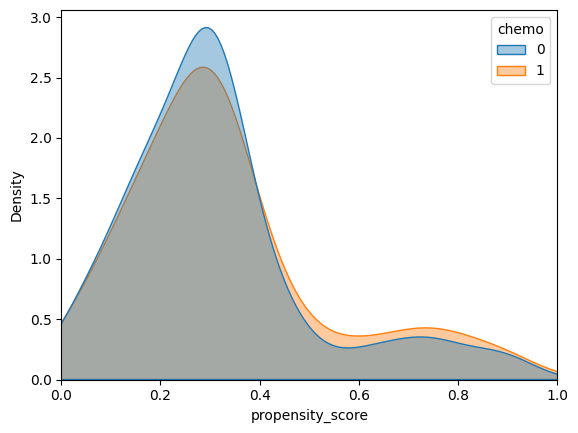

In [10]:
sns.kdeplot(
    data=df_matched,
    x="propensity_score",
    hue="chemo",
    common_norm=False,
    fill=True,
    alpha=0.4
)
plt.xlim(0, 1)  
plt.show()

In [11]:
df_matched.drop(columns = ["propensity_score"], inplace=True)
df_matched.to_csv(f"../data/matched_cohort_1to{matching_ratio}.csv", index = False)

#### We could compare covariate distribution before and after matching

In [12]:
table_one = create_table_one(
    data=df_matched,
    treatment_col="chemo",
    features=baseline_covariates,
    with_std=True,
    with_counts=True,
)

table_one

,Control,Treatment,SMD
Variable,,,
n,330,173,
age,33.97 (13.58),35.16 (13.54),0.0876
extranod,0.06 (0.24),0.13 (0.33),0.2292
female,0.48 (0.50),0.45 (0.50),-0.0619
medwidsi_N,0.52 (0.50),0.47 (0.50),-0.112
medwidsi_S,0.41 (0.49),0.35 (0.48),-0.1101
stage2,0.77 (0.42),0.84 (0.36),0.1885


### Ideas for Exercises / Questions

- matching ratio 1 to 1 --> 1 to 1 gives larger overlap but fewer patients --> question e.g., do you expect propensity overlap to increase with matching ratio set to 1 to 1, what are the drawbacks of this
- compare / analyze covariate balance before and after matching (maybe also with the different matching ratios --> lower ratio, better balance not only in ps but also in the underlying covariates)
- vary parameters in estimate_propensity (learners) or control matching (caliper, replacement) --> did not try out which effect this has yet, the other questions might be more straight forward